# 🤖 Entrenamiento del Modelo con Scikit-Learn

**Objetivo:** Utilizar el dataset de resultados internacionales limpio para entrenar modelos de Machine Learning clásico (Clasificación). Queremos predecir el resultado de un partido: Victoria Local, Empate o Victoria Visitante.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sys.path.append('../')
from src.utils import obtener_conexion

## 1. Carga de Datos Limpios

In [19]:
df = pd.read_csv('../datasets/processed/partidos_internacionales_limpios.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (15860, 10)


,date,home_team,away_team,home_score,away_score,tournament,country,neutral,year,tipo_torneo
0,2010-01-02,Iran,North Korea,1,0,Friendly,Qatar,True,2010,amistoso
1,2010-01-02,Qatar,Mali,0,0,Friendly,Qatar,False,2010,amistoso
2,2010-01-02,Syria,Zimbabwe,6,0,Friendly,Malaysia,True,2010,amistoso
3,2010-01-02,Yemen,Tajikistan,0,1,Friendly,Yemen,False,2010,amistoso
4,2010-01-03,Angola,Gambia,1,1,Friendly,Portugal,True,2010,amistoso


## 2. Ingeniería de Variables (Feature Engineering)
Vamos a crear características matemáticas para que los algoritmos puedan predecir. 
El resultado será nuestra variable `y` (target).

In [20]:
# Variable objetivo: resultado del partido
# 2 = gana local, 1 = empate, 0 = gana visitante
def determinar_resultado(row):
    if row['home_score'] > row['away_score']:
        return 2
    elif row['home_score'] == row['away_score']:
        return 1
    else:
        return 0

df['resultado'] = df.apply(determinar_resultado, axis=1)

# Feature: estadísticas históricas de goles por equipo
df_home = df.groupby('home_team').agg(
    goles_favor_local=('home_score', 'mean'),
    goles_contra_local=('away_score', 'mean')
).reset_index().rename(columns={'home_team': 'equipo'})

df_away = df.groupby('away_team').agg(
    goles_favor_visit=('away_score', 'mean'),
    goles_contra_visit=('home_score', 'mean')
).reset_index().rename(columns={'away_team': 'equipo'})

estadisticas = pd.merge(df_home, df_away, on='equipo', how='outer').fillna(0)
estadisticas['ataque'] = (estadisticas['goles_favor_local'] + estadisticas['goles_favor_visit']) / 2
estadisticas['defensa'] = (estadisticas['goles_contra_local'] + estadisticas['goles_contra_visit']) / 2
print(estadisticas.head())

        equipo  goles_favor_local  goles_contra_local  goles_favor_visit  \
0     Abkhazia           1.826087            0.565217           1.200000   
1  Afghanistan           1.324324            1.135135           1.000000   
2      Albania           1.134831            1.011236           0.945205   
3     Alderney           0.550000            3.750000           1.000000   
4      Algeria           2.250000            0.777778           1.549451   

   goles_contra_visit    ataque   defensa  
0            1.300000  1.513043  0.932609  
1            1.661290  1.162162  1.398213  
2            1.178082  1.040018  1.094659  
3            4.153846  0.775000  3.951923  
4            1.065934  1.899725  0.921856  


In [21]:
# Integramos estas estadísticas de ataque y defensa por partido
df = df.merge(estadisticas[['equipo','ataque','defensa']], left_on='home_team', right_on='equipo', how='left')
df.rename(columns={'ataque': 'ataque_local', 'defensa': 'defensa_local'}, inplace=True)
df.drop(columns=['equipo'], inplace=True)

df = df.merge(estadisticas[['equipo','ataque','defensa']], left_on='away_team', right_on='equipo', how='left')
df.rename(columns={'ataque': 'ataque_visit', 'defensa': 'defensa_visit'}, inplace=True)
df.drop(columns=['equipo'], inplace=True)

# Otras features
df['es_neutral'] = df['neutral'].astype(int)
torneo_map = {'mundial': 4, 'eliminatoria': 3, 'copa_continental': 2, 'amistoso': 1, 'otro': 1}
df['peso_torneo'] = df['tipo_torneo'].map(torneo_map).fillna(1)

FEATURES = ['ataque_local', 'defensa_local', 'ataque_visit', 'defensa_visit', 'es_neutral', 'peso_torneo']
df_modelo = df[FEATURES + ['resultado', 'year']].dropna()
df_modelo.head()

,ataque_local,defensa_local,ataque_visit,defensa_visit,es_neutral,peso_torneo,resultado,year
0,1.932615,0.667453,1.467599,1.183433,1,1,2,2010
1,1.446338,1.237654,1.419531,0.895737,0,1,1,2010
2,1.419540,1.197066,1.252406,1.133921,1,1,2,2010
3,0.890186,1.654907,1.391103,1.294486,0,1,0,2010
4,1.003892,0.929639,1.147755,1.293905,1,1,1,2010


## 3. División Train/Test (Temporal)
En vez de usar un `train_test_split` aleatorio, hacemos una división temporal estricta para evitar la filtración de datos del futuro.

In [22]:
X = df_modelo[FEATURES]
y = df_modelo['resultado']
years = df_modelo['year']

# Entrenamiento hasta 2022, Prueba con 2023+
X_train = X[years < 2023]
X_test  = X[years >= 2023]
y_train = y[years < 2023]
y_test  = y[years >= 2023]

print(f'Train: {X_train.shape[0]} partidos')
print(f'Test: {X_test.shape[0]} partidos')

Train: 12219 partidos
Test: 3641 partidos


## 4. Entrenamiento y Comparativa de Modelos

In [23]:
modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'{nombre} - Accuracy Test: {acc:.3f}')

Regresión Logística - Accuracy Test: 0.593
Random Forest - Accuracy Test: 0.552
Gradient Boosting - Accuracy Test: 0.600


## 5. Análisis del Mejor Modelo (Random Forest)

                precision    recall  f1-score   support

Visitante gana       0.54      0.53      0.53      1079
        Empate       0.29      0.18      0.22       840
    Local gana       0.63      0.75      0.68      1722

      accuracy                           0.55      3641
     macro avg       0.48      0.49      0.48      3641
  weighted avg       0.52      0.55      0.53      3641



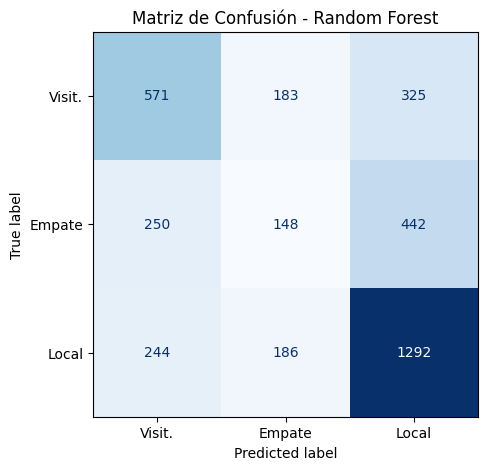

In [24]:
rf = modelos['Random Forest']
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=['Visitante gana','Empate','Local gana']))

fig, ax = plt.subplots(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['Visit.', 'Empate', 'Local'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión - Random Forest')
plt.show()

## 6. Importancia de Variables (Feature Importance)

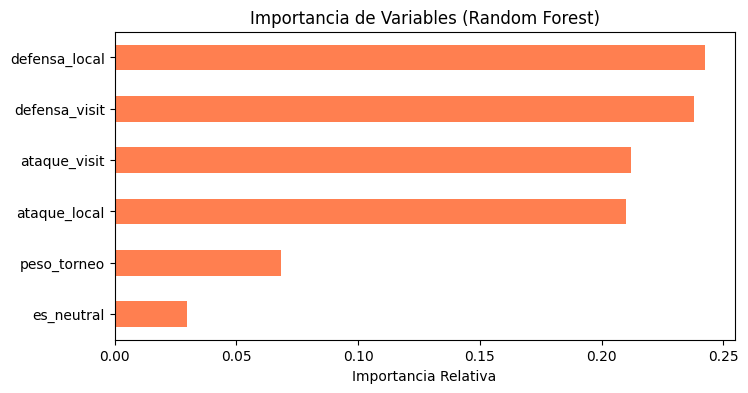

In [25]:
importancias = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
importancias.plot(kind='barh', color='coral', figsize=(8,4))
plt.title('Importancia de Variables (Random Forest)')
plt.xlabel('Importancia Relativa')
plt.show()

## 7. Predicción de Ejemplo
Argentina vs Francia en un partido de Mundial (cancha neutral).

In [26]:
def obtener_stats(equipo, df_stats):
    row = df_stats[df_stats['equipo'] == equipo]
    if len(row) == 0:
        return {'ataque': 1.0, 'defensa': 1.0}
    return {'ataque': row['ataque'].values[0], 'defensa': row['defensa'].values[0]}

stats_arg = obtener_stats('Argentina', estadisticas)
stats_fra = obtener_stats('France', estadisticas)

partido = pd.DataFrame([{
    'ataque_local': stats_arg['ataque'],
    'defensa_local': stats_arg['defensa'],
    'ataque_visit': stats_fra['ataque'],
    'defensa_visit': stats_fra['defensa'],
    'es_neutral': 1,
    'peso_torneo': 4
}])

proba = rf.predict_proba(partido)[0]
print('Probabilidades Argentina vs Francia (Cancha Neutral):')
print(f'Gana Francia: {proba[0]*100:.1f}%')
print(f'Empate:       {proba[1]*100:.1f}%')
print(f'Gana Argentina: {proba[2]*100:.1f}%')

Probabilidades Argentina vs Francia (Cancha Neutral):
Gana Francia: 18.2%
Empate:       68.0%
Gana Argentina: 13.8%
